# Step 3 (3D) — Preprocessing Locale: Split + Riorganizzazione Volumi
**Goals** (fase LOCALE della Dicotomia Locale/Cloud — nessuna normalizzazione numerica qui):
1. Scansionare tutte le maschere `_seg.nii.gz` grezze e calcolare Tumour Burden + ET-presence (5 classi native)
2. Costruire uno split stratificato Train/Val/Test (80/10/10) fedele alla Strategia C del vecchio progetto 2D
3. Esportare lo split in `data/split_3d.json`
4. **Copia Fisica** dei volumi NIfTI grezzi in `data/processed_3d/{train,val,test}/` (NESSUNA estrazione di slice `.npy`: quella logica del vecchio progetto 2D non si applica qui — il training 3D su Colab legge i NIfTI interi on-the-fly via MONAI transforms)

**Differenza critica rispetto al vecchio progetto 2D (`master/notebooks/02_preprocessing.ipynb`)**:
- Il vecchio conteggio 'ET presence' usava la label 3 DOPO la remap `4->3` (mescolando il vero ET con parte di CC/ED). Qui si usano le **5 classi native**: ET e' la label 1 pura.
- Il vecchio notebook estraeva ~40.000 slice 2D `.npy` con normalizzazione (clip P99.5 + z-score) applicata offline. Qui si copiano i NIfTI **grezzi, senza alcuna normalizzazione**: la normalizzazione (`ClipAndNormalizeNonZerod`, replica esatta della logica 2D generalizzata a volumi 3D) vive in `src/transforms_3d.py` ed e' applicata on-the-fly durante il training su Colab, non offline in locale.

In [1]:
import os
import sys
import json
import shutil
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split

sys.path.insert(0, os.path.abspath('..'))
from src.constants import NUM_CLASSES, CLASS_NAMES

TRAIN_DIR = os.path.join('..', 'data', 'raw', 'BraTS-PEDs-v1', 'Training')
SPLIT_PATH = os.path.join('..', 'data', 'split_3d.json')
OUT_BASE = os.path.join('..', 'data', 'processed_3d')
SEED = 42

subjects = sorted(os.listdir(TRAIN_DIR))
print(f'Total subjects: {len(subjects)}')
print(f'NUM_CLASSES = {NUM_CLASSES}, CLASS_NAMES = {CLASS_NAMES}')

Total subjects: 257
NUM_CLASSES = 5, CLASS_NAMES = ('background', 'ET', 'NET', 'CC', 'ED')


## 1. Missing Values & Integrita' dei File (5 modalita' attese per soggetto)

Verifica preliminare: ogni soggetto deve avere i 4 volumi MRI + la segmentazione. A differenza del vecchio notebook 2D (che faceva anche un controllo di outlier/NaN sulle intensita'), qui NON si ispezionano i valori numerici delle intensita' — quel controllo (clip P99.5, z-score) e' delegato interamente a `ClipAndNormalizeNonZerod` su Colab. Qui si verifica solo la presenza dei file.

In [2]:
MODALITIES = ['t1c', 't1n', 't2f', 't2w']

missing_report = []
for subj in tqdm(subjects, desc='Verifica integrita\' file'):
    subj_dir = os.path.join(TRAIN_DIR, subj)
    expected = [f'{subj}-{mod}.nii.gz' for mod in MODALITIES] + [f'{subj}-seg.nii.gz']
    missing = [f for f in expected if not os.path.isfile(os.path.join(subj_dir, f))]
    if missing:
        missing_report.append((subj, missing))

if missing_report:
    print(f'ATTENZIONE: {len(missing_report)} soggetti con file mancanti:')
    for subj, missing in missing_report:
        print(f'  {subj}: {missing}')
else:
    print(f'OK: tutti i {len(subjects)} soggetti hanno i 5 file NIfTI attesi (4 modalita\' + seg).')

Verifica integrita' file:   0%|          | 0/257 [00:00<?, ?it/s]

Verifica integrita' file: 100%|██████████| 257/257 [00:00<00:00, 4718.33it/s]

OK: tutti i 257 soggetti hanno i 5 file NIfTI attesi (4 modalita' + seg).


## 2. Normalizzazione — demo (NON applicata qui, solo dimostrativa)

Il vecchio notebook 2D applicava clip-P99.5 + z-score **offline**, salvando gli array normalizzati su disco. Qui la stessa identica logica (`ClipAndNormalizeNonZerod`, verificata numericamente equivalente al vecchio schema — si veda `tests/test_transforms_3d.py`) e' invece applicata **on-the-fly su Colab**, dentro `src/transforms_3d.py`. Questa cella mostra solo l'effetto della trasformazione a scopo illustrativo, senza scrivere nulla su disco.

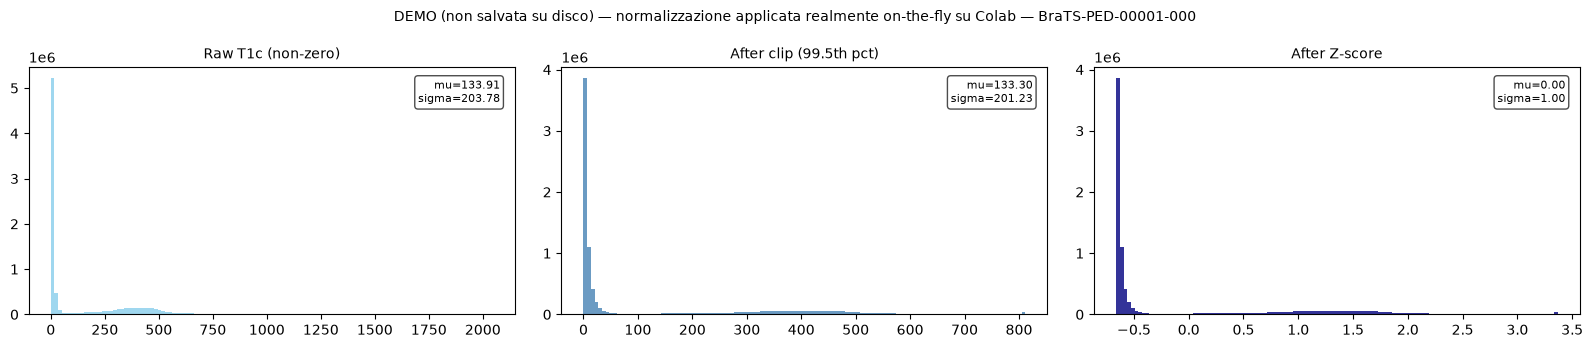

NOTA: nessun file .npy normalizzato viene scritto — questa e' solo una demo visiva.


In [3]:
demo_id = subjects[0]
demo_dir = os.path.join(TRAIN_DIR, demo_id)
t1c_raw = nib.load(os.path.join(demo_dir, f'{demo_id}-t1c.nii.gz')).get_fdata().astype(np.float32)

brain = t1c_raw > 0
upper = np.percentile(t1c_raw[brain], 99.5)
t1c_clip = np.clip(t1c_raw, 0, upper)
mu, sigma = t1c_clip[brain].mean(), t1c_clip[brain].std()
t1c_norm = np.zeros_like(t1c_raw)
t1c_norm[brain] = (t1c_clip[brain] - mu) / sigma

fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
stages = [(t1c_raw, 'Raw T1c (non-zero)', 'skyblue'),
          (t1c_clip, 'After clip (99.5th pct)', 'steelblue'),
          (t1c_norm, 'After Z-score', 'navy')]
for ax, (vol, title, col) in zip(axes, stages):
    vals = vol[brain].flatten()
    ax.hist(vals, bins=120, color=col, edgecolor='none', alpha=0.8)
    ax.set_title(title, fontsize=10)
    ax.text(0.97, 0.95, f'mu={vals.mean():.2f}\nsigma={vals.std():.2f}',
            ha='right', va='top', transform=ax.transAxes, fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
plt.suptitle(f'DEMO (non salvata su disco) — normalizzazione applicata realmente on-the-fly su Colab — {demo_id}', fontsize=10)
plt.tight_layout()
plt.savefig('preproc_3d_normalisation_demo.png', dpi=120, bbox_inches='tight')
plt.show()
print('NOTA: nessun file .npy normalizzato viene scritto — questa e\' solo una demo visiva.')

## 3. Estrazione Metadati — Tumour Burden + ET-presence (5 classi native)

Per ciascun soggetto, si conta il volume di ogni classe tumorale nativa direttamente dalla maschera grezza (nessuna remap):
- `n_et`   = voxel di label 1 (Enhancing Tumor, pura)
- `n_net`  = voxel di label 2 (Non-Enhancing Tumor)
- `n_cc`   = voxel di label 3 (Cystic Component)
- `n_ed`   = voxel di label 4 (Peritumoral Edema)
- `n_tumour` (Tumour Burden) = somma delle 4 classi sopra (tutti i voxel non-background)
- `has_et` (ET-presence) = `n_et > 0`

In [4]:
tumour_stats = []

for subj in tqdm(subjects, desc='Computing tumour stats (5-class native)'):
    seg_path = os.path.join(TRAIN_DIR, subj, f'{subj}-seg.nii.gz')
    seg = nib.load(seg_path).get_fdata().astype(np.int16)

    n_et = int((seg == 1).sum())
    n_net = int((seg == 2).sum())
    n_cc = int((seg == 3).sum())
    n_ed = int((seg == 4).sum())
    n_tumour = n_et + n_net + n_cc + n_ed

    tumour_stats.append({
        'subject_id': subj,
        'n_et': n_et, 'n_net': n_net, 'n_cc': n_cc, 'n_ed': n_ed,
        'n_tumour': n_tumour,
        'has_et': n_et > 0,
    })

tumour_vols = np.array([s['n_tumour'] for s in tumour_stats])
et_presence = np.array([s['has_et'] for s in tumour_stats])

print(f'Tumour volume (Tumour Burden, 5-classi) — min: {tumour_vols.min()}  max: {tumour_vols.max()}  mean: {tumour_vols.mean():.0f}')
print(f'Subjects with ET (label 1 pura) present: {et_presence.sum()} / {len(et_presence)} ({100*et_presence.mean():.1f}%)')
print(f'\nConfronto col vecchio progetto 2D: la\' il conteggio ET (post-remap) era 42.0% (108/257).')
print(f'Qui, con le label native, e\' {100*et_presence.mean():.1f}% — conferma che la vecchia label 3 fusa')
print(f'mescolava classi diverse e sottostimava la prevalenza clinica reale di ET.')

Computing tumour stats (5-class native):   0%|          | 0/257 [00:00<?, ?it/s]

Computing tumour stats (5-class native):   1%|          | 2/257 [00:00<00:23, 10.70it/s]

Computing tumour stats (5-class native):   2%|▏         | 4/257 [00:00<00:23, 10.55it/s]

Computing tumour stats (5-class native):   2%|▏         | 6/257 [00:00<00:24, 10.40it/s]

Computing tumour stats (5-class native):   3%|▎         | 8/257 [00:00<00:23, 10.40it/s]

...

Computing tumour stats (5-class native):  98%|█████████▊| 252/257 [00:23<00:00, 10.95it/s]

Computing tumour stats (5-class native):  99%|█████████▉| 254/257 [00:24<00:00, 10.91it/s]

Computing tumour stats (5-class native): 100%|█████████▉| 256/257 [00:24<00:00, 10.75it/s]

Computing tumour stats (5-class native): 100%|██████████| 257/257 [00:24<00:00, 10.57it/s]

Tumour volume (Tumour Burden, 5-classi) — min: 854  max: 270472  mean: 53506
Subjects with ET (label 1 pura) present: 171 / 257 (66.5%)

Confronto col vecchio progetto 2D: la' il conteggio ET (post-remap) era 42.0% (108/257).
Qui, con le label native, e' 66.5% — conferma che la vecchia label 3 fusa
mescolava classi diverse e sottostimava la prevalenza clinica reale di ET.


## 4. Stratificazione — Quartili di Tumour Burden + ET-presence (categoria composita)

Fedele alla **Strategia C** del vecchio progetto 2D (`master/notebooks/02_preprocessing.ipynb`, sezione 5-8), ma ricalcolata sulle 5 classi native:

1. Quartili di `tumour_vols` (4 bin: 0..3) via `np.digitize` sui percentili 25/50/75.
2. Categoria composita: `combined_label = et_presence * 4 + quartile` (fino a 8 bin: 4 quartili x 2 stati ET).
3. **Un solo** `train_test_split` stratificato su `combined_label` per Train/tmp (80/20), poi un secondo per Val/Test (50/50 del tmp) — non due split separati per quartile ed ET.

In [5]:
indices = list(range(len(tumour_stats)))
quartiles = np.digitize(tumour_vols, np.percentile(tumour_vols, [25, 50, 75]))
combined_label = (et_presence.astype(int) * 4 + quartiles).tolist()

train_idx, tmp_idx, _, tmp_labels = train_test_split(
    indices, combined_label, test_size=0.20, stratify=combined_label, random_state=SEED
)
val_idx, test_idx = train_test_split(
    tmp_idx, test_size=0.50, stratify=tmp_labels, random_state=SEED
)

print(f'Train: {len(train_idx)}  Val: {len(val_idx)}  Test: {len(test_idx)}')

Train: 205  Val: 26  Test: 26


## 5. Verifica Qualita' dello Split

--- Qualita' dello split (5 classi native) ---
  Train (205): tumour   53034 ±  47087  ET rate  66.3%
  Val   ( 26): tumour   52294 ±  40317  ET rate  69.2%
  Test  ( 26): tumour   58444 ±  59651  ET rate  65.4%


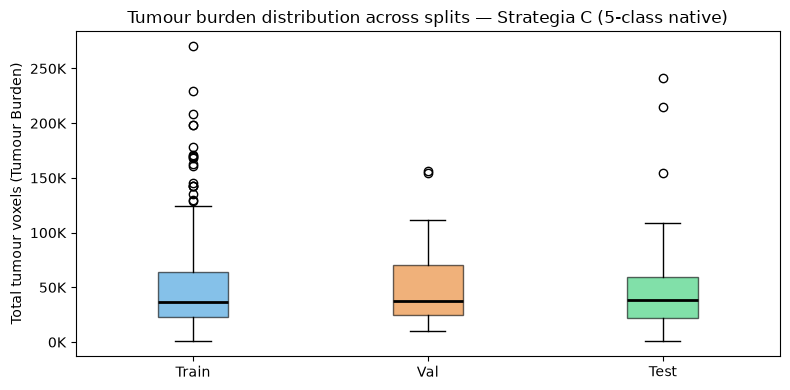

In [6]:
def _split_report(name, idx):
    vols = tumour_vols[idx]
    et = et_presence[idx]
    print(f'  {name:5s} ({len(idx):3d}): tumour {vols.mean():7.0f} ± {vols.std():6.0f}  ET rate {100*et.mean():5.1f}%')

print('--- Qualita\' dello split (5 classi native) ---')
_split_report('Train', train_idx)
_split_report('Val', val_idx)
_split_report('Test', test_idx)

fig, ax = plt.subplots(figsize=(8, 4))
data = [tumour_vols[train_idx], tumour_vols[val_idx], tumour_vols[test_idx]]
bp = ax.boxplot(data, tick_labels=['Train', 'Val', 'Test'], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#3498db', '#e67e22', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Total tumour voxels (Tumour Burden)')
ax.set_title('Tumour burden distribution across splits — Strategia C (5-class native)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('preproc_3d_split_quality.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Decisione & Export dello Split → `data/split_3d.json`

In [7]:
chosen_train = [tumour_stats[i]['subject_id'] for i in train_idx]
chosen_val = [tumour_stats[i]['subject_id'] for i in val_idx]
chosen_test = [tumour_stats[i]['subject_id'] for i in test_idx]

split_dict = {
    'strategy': 'C \u2014 Stratified by ET presence (native label 1) + tumour burden quartile, 5-class scheme',
    'label_scheme': {'0': 'background', '1': 'ET', '2': 'NET', '3': 'CC', '4': 'ED'},
    'seed': SEED,
    'train': chosen_train,
    'val': chosen_val,
    'test': chosen_test,
    'sizes': {'train': len(chosen_train), 'val': len(chosen_val), 'test': len(chosen_test)},
}

os.makedirs(os.path.dirname(SPLIT_PATH), exist_ok=True)
with open(SPLIT_PATH, 'w') as f:
    json.dump(split_dict, f, indent=2)

print(f'{SPLIT_PATH} salvato.')
print(f'  Train: {len(chosen_train)} soggetti')
print(f'  Val:   {len(chosen_val)} soggetti')
print(f'  Test:  {len(chosen_test)} soggetti')

..\data\split_3d.json salvato.
  Train: 205 soggetti
  Val:   26 soggetti
  Test:  26 soggetti


## 7. Copia Fisica dei Volumi NIfTI — `data/processed_3d/{train,val,test}/`

**NIENTE ESTRAZIONE 2D.** A differenza del vecchio notebook 2D (che qui estraeva ~40.000 slice `.npy` con normalizzazione offline), questa cella fa **solo Copia Fisica**: i 5 file NIfTI grezzi (4 modalita' + seg) di ciascun soggetto vengono copiati cosi' come sono — senza alcuna modifica — mantenendo una sottocartella per paziente, secondo lo split appena generato.

```
data/processed_3d/
    train/<subject_id>/<subject_id>-{t1c,t1n,t2f,t2w,seg}.nii.gz   (205 soggetti)
    val/...                                                         (26 soggetti)
    test/...                                                        (26 soggetti)
```

Questa struttura e' pronta per essere compressa/trasferita su Colab, dove `src/dataset_3d.py` (MONAI transforms: `ClipAndNormalizeNonZerod`, `RandCropByPosNegLabeld`, ...) la consuma direttamente on-the-fly.

> Nota: questa stessa logica di copia e' gia' disponibile come script standalone in `scripts/reorganize_volumes.py` (gia' eseguito ed integrita'-verificato su tutti i 257 soggetti — si veda `pipeline3D.md`, Punto 2). Questo notebook la rende disponibile anche in forma interattiva, simmetrica al vecchio `02_preprocessing.ipynb` 2D.

In [8]:
def copy_subject(subject_id: str, dst_split_dir: str) -> None:
    """Copia i 5 file NIfTI grezzi di un soggetto (Copia Fisica, nessuna modifica)."""
    src_dir = os.path.join(TRAIN_DIR, subject_id)
    dst_dir = os.path.join(dst_split_dir, subject_id)
    os.makedirs(dst_dir, exist_ok=True)

    files = [f'{subject_id}-{mod}.nii.gz' for mod in MODALITIES]
    files.append(f'{subject_id}-seg.nii.gz')

    for fname in files:
        src = os.path.join(src_dir, fname)
        dst = os.path.join(dst_dir, fname)
        if not os.path.isfile(src):
            raise FileNotFoundError(f'File atteso mancante: {src}')
        shutil.copy2(src, dst)


print('Starting physical copy (NIfTI grezzi, nessuna estrazione/normalizzazione)...\n')

total_copied = 0
for split_name, subject_ids in [('train', chosen_train), ('val', chosen_val), ('test', chosen_test)]:
    dst_split_dir = os.path.join(OUT_BASE, split_name)
    os.makedirs(dst_split_dir, exist_ok=True)

    for subj in tqdm(subject_ids, desc=f'[{split_name:5s}] Copying'):
        copy_subject(subj, dst_split_dir)
        total_copied += 1

    print(f'  {split_name}: {len(subject_ids)} soggetti copiati -> {dst_split_dir}')

print(f'\nTotale soggetti copiati: {total_copied}')
print(f'Output: {os.path.abspath(OUT_BASE)}')

Starting physical copy (NIfTI grezzi, nessuna estrazione/normalizzazione)...



[train] Copying:   0%|          | 0/205 [00:00<?, ?it/s]

[train] Copying:   1%|          | 2/205 [00:00<00:13, 14.89it/s]

[train] Copying:   2%|▏         | 4/205 [00:03<03:19,  1.01it/s]

[train] Copying:   2%|▏         | 5/205 [00:03<02:35,  1.28it/s]

...

[test ] Copying:  92%|█████████▏| 24/26 [00:17<00:02,  1.18s/it]

[test ] Copying:  96%|█████████▌| 25/26 [00:19<00:01,  1.37s/it]

[test ] Copying: 100%|██████████| 26/26 [00:20<00:00,  1.21s/it]

[test ] Copying: 100%|██████████| 26/26 [00:20<00:00,  1.27it/s]

  test: 26 soggetti copiati -> ..\data\processed_3d\test

Totale soggetti copiati: 257
Output: C:\Users\lrnzp\OneDrive\Desktop\Progetto AI in Medicine\BraTS-PEDs-3D\data\processed_3d


## 8. Verifica di Integrita' Post-Copia

In [9]:
print(f'{"Split":<8} {"Cartelle":>9}  {"File .nii.gz":>13}  {"Attesi":>8}')
print('-' * 50)

all_ok = True
for split_name in ['train', 'val', 'test']:
    split_dir = os.path.join(OUT_BASE, split_name)
    subj_dirs = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    n_files = sum(
        len([f for f in os.listdir(os.path.join(split_dir, d)) if f.endswith('.nii.gz')])
        for d in subj_dirs
    )
    expected = len(subj_dirs) * 5
    ok = n_files == expected
    all_ok &= ok
    print(f'{split_name:<8} {len(subj_dirs):>9}  {n_files:>13}  {expected:>8}  {"OK" if ok else "MISMATCH"}')

# Controllo a campione: verifica che i file siano leggibili e le label nel range atteso
import random
random.seed(0)
errors = []
for split_name in ['train', 'val', 'test']:
    split_dir = os.path.join(OUT_BASE, split_name)
    subj_dirs = sorted(os.listdir(split_dir))
    sample = random.sample(subj_dirs, min(3, len(subj_dirs)))
    for subj in sample:
        seg_path = os.path.join(split_dir, subj, f'{subj}-seg.nii.gz')
        try:
            data = nib.load(seg_path).get_fdata().astype(np.int16)
            labels = sorted(int(x) for x in np.unique(data))
            if any(l < 0 or l >= NUM_CLASSES for l in labels):
                errors.append(f'{seg_path}: unexpected labels {labels}')
        except Exception as e:
            errors.append(f'{seg_path}: {e}')

print(f'\nControllo a campione (9 soggetti, 3 per split): {"OK, nessun errore" if not errors else errors}')
print('\n=> Preprocessing locale (3D) completo.' if all_ok and not errors else '\n=> ATTENZIONE: verificare i mismatch sopra.')

Split     Cartelle   File .nii.gz    Attesi
--------------------------------------------------
train          205           1025      1025  OK
val             26            130       130  OK
test            26            130       130  OK



Controllo a campione (9 soggetti, 3 per split): OK, nessun errore

=> Preprocessing locale (3D) completo.


## 9. Summary

In [ ]:
print('=== Step 3 (3D) — Preprocessing Locale Summary ===')

print('\n[1. Integrita\' file]')
print(f'  Soggetti verificati: {len(subjects)}  |  file mancanti: {len(missing_report)}')

print('\n[2. Normalizzazione]')
print('  NON applicata qui — vive in src/transforms_3d.py::ClipAndNormalizeNonZerod,')
print('  eseguita on-the-fly durante il training su Colab (Dicotomia Locale/Cloud).')

print('\n[3. Label — 5 classi native]')
print('  NESSUNA remap (a differenza del vecchio 2D, che fondeva 4->3).')
print(f'  Classi: {dict(enumerate(CLASS_NAMES))}')
print(f'  ET-presence: {100*et_presence.mean():.1f}% (vs 42.0% del vecchio conteggio post-remap)')

print('\n[4. Split — Strategia C (5-class native)]')
print(f'  Train  : {len(chosen_train)} soggetti')
print(f'  Val    : {len(chosen_val)} soggetti')
print(f'  Test   : {len(chosen_test)} soggetti')
print(f'  Saved  : {SPLIT_PATH}')

print('\n[5. Copia Fisica — NIENTE estrazione .npy]')
print(f'  Root       : {os.path.abspath(OUT_BASE)}/')
print(f'  Soggetti copiati: {total_copied} (5 file NIfTI grezzi ciascuno, nessuna modifica)')
print('  Pronto per compressione/trasferimento a Colab (src/dataset_3d.py legge da qui).')

print('\n=> Preprocessing locale 3D completo. Prossimo passo: training su Colab/A100')
print('   (run_pipeline_3d.py --arch {segresnet,swinunetr} --loss {dice_focal,gsl}, oppure --all).')